In [1]:
%load_ext autoreload
%autoreload 2

from Utils import Notebook
from Utils import Tex
from Utils import Graphs
from IPython.display import Math, display
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la
import json

from IPython.display import display, Math, Latex,Markdown

import ControllerDesigner, Engine


Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
experiment_config_filename = "sys-01"
config_path = fr"../../data/lit-systems/{experiment_config_filename}.json"

with open(config_path, "r", encoding="utf-8") as f:
  plant_data = json.load(f)

plant_matrices = plant_data["system_matrices"]
A = np.array(plant_matrices["A"], dtype=np.float64)
B = np.array(plant_matrices["B"], dtype=np.float64)
C = np.array(plant_matrices["C"], dtype=np.float64)

results = ControllerDesigner.check_system_properties(A, B, C)

print("=" * 60)
print("SYSTEM PROPERTIES")
print("=" * 60)
print(
    f"Controllability rank : {results['controllability_rank']} / {A.shape[0]}")
print(f"Observability rank   : {results['observability_rank']} / {A.shape[0]}")
print(f"Controllable         : {results['controllable']}")
print(f"Observable           : {results['observable']}")
print(f"Stabilizable         : {results['stabilizable']}")
print(f"Detectable           : {results['detectable']}")

print("\nEigenvalues of A:")
for eig in results["eigenvalues"]:
  print(f"  {eig:.2f}")
print("=" * 60)

print("\nEquações que regem a dinâmica da planta:")
A_latex_expr = Tex.mat2tex(A)
B_latex_expr = Tex.mat2tex(B)
C_latex_expr = Tex.mat2tex(C)
display(Math(rf"\dot{{x}}(t) = {A_latex_expr} x(t) + {B_latex_expr} u(t)"))
display(Math(rf"y(t) = {C_latex_expr} x(t)"))

sim_engine = Engine.Engine(dll_path="dll/petc_for_lit_systems.dll")
sim_engine.load_lit_model(config_path)

print(f"\n[Engine] Modelo carregado com sucesso via DLL: {config_path}")
print(
    f"Dimensões detectadas -> Estados (nx): {sim_engine.nx}, Entradas (nu):"
    f" {sim_engine.nu}, Saídas (ny): {sim_engine.ny}"
)

SYSTEM PROPERTIES
Controllability rank : 2 / 2
Observability rank   : 2 / 2
Controllable         : True
Observable           : True
Stabilizable         : True
Detectable           : True

Eigenvalues of A:
  0.20+1.99j
  0.20-1.99j

Equações que regem a dinâmica da planta:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


[Engine] Modelo carregado com sucesso via DLL: ../../data/lit-systems/sys-01.json
Dimensões detectadas -> Estados (nx): 2, Entradas (nu): 1, Saídas (ny): 1


### Co-projeto do Controlador baseado em Eventos

In [3]:
h = 1e-3
lambd = 1e-2

upsilon1 = 1e-2
upsilon2 = 1e-2
upsilon3 = 0.5
upsilon4 = 0.5

T2 = np.array([
    [0.0, 1.0]
], dtype=np.float64)

ctrl_params = {'A': A, 'B': B, 'C': C, 'T2': T2, 'h': h, 'λ': lambd,
               'υ1': upsilon1, 'υ2': upsilon2, 'υ3': upsilon3, 'υ4': upsilon4, }

synth_res = ControllerDesigner.synthesize_output_based_setm(
    ctrl_params, eps=1e-6, verbose=False)

if synth_res is None:
  print("ERRO: Síntese Infeasible ou falha na recuperação das matrizes.")
else:
  K = synth_res['controller']['K']
  P = synth_res['functional']['P']
  R = synth_res['functional']['R']
  Ψ_sc = synth_res['etm']['sc']['Ψ']
  Ξ_sc = synth_res['etm']['sc']['Ξ']
  Ψ_ca = synth_res['etm']['ca']['Ψ']
  Ξ_ca = synth_res['etm']['ca']['Ξ']
  eig_cl = np.linalg.eigvals(A + B @ K)
  print("=== SÍNTESE CONCLUÍDA COM SUCESSO ===")
  print(f"Status do Solver: {synth_res['solver_status']}")
  print(f"Autovalores Nominais de Malha Fechada: {np.round(eig_cl, 4)}")

  display(Math(rf"""
    \begin{{aligned}}
        K &= {Tex.mat2tex(K)}, \qquad 
        P = {Tex.mat2tex(P)}, \qquad 
        R = {Tex.mat2tex(R)} \\[10pt]
        \Psi_{{\mathrm{{sc}}}} &= {Tex.mat2tex(Ψ_sc)}, \qquad 
        \Xi_{{\mathrm{{sc}}}} = {Tex.mat2tex(Ξ_sc)} \\[10pt]
        \Psi_{{\mathrm{{ca}}}} &= {Tex.mat2tex(Ψ_ca)}, \qquad 
        \Xi_{{\mathrm{{ca}}}} = {Tex.mat2tex(Ξ_ca)}
    \end{{aligned}}
    """))

=== SÍNTESE CONCLUÍDA COM SUCESSO ===
Status do Solver: optimal
Autovalores Nominais de Malha Fechada: [-1.9466+0.4368j -1.9466-0.4368j]


<IPython.core.display.Math object>

### Projeto do Observador Impulsivo

In [4]:
cont_design = ControllerDesigner.synthesize_continuous_gains(
    A=A, C=C, alpha_0=1.1, alpha_z=20, g0_method="analytical", verbose=False
)

nu_bar_sc = 500

obs_result = None
if cont_design is not None:
  observer_params = {
      "A": A, "C": C, "h": h, "nu_bar": nu_bar_sc * h,
      "lambda_obs": 22 * lambd, "L0": cont_design["L0"], "L2": cont_design["L2"],
  }
  obs_result = ControllerDesigner.synthesize_impulsive_observer(
      observer_params, q_min=1.0
  )

if (
    cont_design is not None
    and obs_result is not None
):
  print("=== SÍNTESE CONCLUÍDA COM SUCESSO ===")

  G0, G1, G2 = cont_design["G0"], cont_design["G1"], cont_design["G2"]
  L0, L2 = cont_design["L0"], cont_design["L2"]
  L1 = obs_result["L1"]
  worst_spec = obs_result["worst_case"]["spectral_radius"]

  print(
      f"Pior raio espectral discreto em nu_bar (Observador):"
      f" {worst_spec:.4f}"
  )
  print(f"Autovalores Nominais de Malha Fechada: {np.round(eig_cl, 4)}")

  display(
      Math(
          rf"""
    \begin{{aligned}}
        G_0 &= {Tex.mat2tex(G0)}, \qquad G_1 = {Tex.mat2tex(G1)}, \qquad G_2 = {Tex.mat2tex(G2)} \\[10pt]
        L_0 &= {Tex.mat2tex(L0)}, \qquad L_2 = {Tex.mat2tex(L2)}, \qquad L_1 = {Tex.mat2tex(L1)}
    \end{{aligned}}
    """
      )
  )
else:
  print(
      "ERRO: Síntese Infactível."
  )

=== SÍNTESE CONCLUÍDA COM SUCESSO ===
Pior raio espectral discreto em nu_bar (Observador): 0.9970
Autovalores Nominais de Malha Fechada: [-1.9466+0.4368j -1.9466-0.4368j]


<IPython.core.display.Math object>

In [5]:
import numpy as np


def format_matrix_to_cpp(mat, name="X", scientific=True):
  """Converte um vetor ou matriz numpy para o formato C++ com chave única:

  X = {val1, val2, val3, ...};
  """
  mat = np.atleast_2d(mat)
  flat_vals = mat.flatten()

  fmt = "{:.2e}" if scientific else "{:.4f}"
  vals_str = ", ".join([fmt.format(val) for val in flat_vals])

  return f"{name} = {{{vals_str}}};"


# Extração das variáveis do novo escopo Dual-Channel
Ξ_sc = synth_res["etm"]["sc"]["Ξ"]
Ψ_sc = synth_res["etm"]["sc"]["Ψ"]
Ξ_ca = synth_res["etm"]["ca"]["Ξ"]
Ψ_ca = synth_res["etm"]["ca"]["Ψ"]
K = synth_res["controller"]["K"]
L0 = obs_result["L0"]
L1 = obs_result["L1"]
L2 = obs_result["L2"]

# Exibição no console / Jupyter no formato exato solicitado
print(format_matrix_to_cpp(Ξ_sc, name="Ξ_sc"))
print(format_matrix_to_cpp(Ψ_sc, name="Ψ_sc"))
print(format_matrix_to_cpp(Ξ_ca, name="Ξ_ca"))
print(format_matrix_to_cpp(Ψ_ca, name="Ψ_ca"))
print(format_matrix_to_cpp(K, name="K"))
print(format_matrix_to_cpp(L0, name="L0"))
print(format_matrix_to_cpp(L1, name="L1"))
print(format_matrix_to_cpp(L2, name="L2"))

Ξ_sc = {1.54e-05};
Ψ_sc = {9.29e+04};
Ξ_ca = {8.69e+04, -6.58e+03, -6.58e+03, 1.96e+06};
Ψ_ca = {8.91e+04, 4.42e+04, 4.42e+04, 1.18e+05};
K = {1.98e-02, -4.29e+00};
L0 = {0.00e+00, 0.00e+00, 0.00e+00, -1.50e+00};
L1 = {1.00e+00, 1.95e+00};
L2 = {4.04e+01, 6.18e+02};


In [6]:
x0 = np.array([-1.0, 1.0], dtype=np.float64)
x_hat0 = np.array([0.0, 0.0], dtype=np.float64)
x_hat_a0 = np.array([0.0, 0.0], dtype=np.float64)

sampling_period = h
duration = 30.0
time_step = 1e-4
max_iet_sc = nu_bar_sc * sampling_period
max_iet_ca = 10.0

results = sim_engine.run_dual_channel_simulation(
    x0=x0, x_hat0=x_hat0, x_hat_a0=x_hat_a0,
    K=K, L0=L0, L1=L1, L2=L2, Psi_sc=Ψ_sc, Xi_sc=Ξ_sc, Psi_ca=Ψ_ca, Xi_ca=Ξ_ca,
    sampling_period=sampling_period, duration=duration, time_step=time_step,
    max_iet_sc=max_iet_sc, max_iet_ca=max_iet_ca,
)

In [7]:
time = results["time"]
sc_trigger_times = results["sc_trigger_times"]
ca_trigger_times = results["ca_trigger_times"]

x1 = results["states"][:, 0]
x2 = results["states"][:, 1]
x_est1 = results["estimated_states"][:, 0]
x_est2 = results["estimated_states"][:, 1]
e1 = results["estimation_error"][:, 0]
e2 = results["estimation_error"][:, 1]
u1 = results["control"][:, 0]

dt = time[1] - time[0]
step_ratio = int(np.round(h / dt))

sample_indices = np.arange(0, len(time), step_ratio)
s_m_times = time[sample_indices]

error_norm = np.sqrt(e1**2 + e2**2)
error_norm_sm = error_norm[sample_indices]

sc_inter_event_times = np.zeros_like(sc_trigger_times)
if len(sc_trigger_times) > 1:
  sc_inter_event_times[1:] = np.diff(sc_trigger_times)
sc_iet_valid = (
    sc_inter_event_times[1:]
    if len(sc_inter_event_times) > 1
    else np.array([0.0])
)
sc_trigger_valid = (
    sc_trigger_times[1:] if len(sc_trigger_times) > 1 else np.array([0.0])
)

sc_iet_mean = float(np.mean(sc_iet_valid))
sc_transmissions = len(sc_trigger_times)

ca_inter_event_times = np.zeros_like(ca_trigger_times)
if len(ca_trigger_times) > 1:
  ca_inter_event_times[1:] = np.diff(ca_trigger_times)
ca_iet_valid = (
    ca_inter_event_times[1:]
    if len(ca_inter_event_times) > 1
    else np.array([0.0])
)
ca_trigger_valid = (
    ca_trigger_times[1:] if len(ca_trigger_times) > 1 else np.array([0.0])
)

ca_iet_mean = float(np.mean(ca_iet_valid))
ca_transmissions = len(ca_trigger_times)

total_samples_sm = len(s_m_times)
sc_reduction_pct = (1.0 - (sc_transmissions / total_samples_sm)) * 100.0
ca_reduction_pct = (1.0 - (ca_transmissions / total_samples_sm)) * 100.0

norm_rms = float(np.sqrt(np.mean(error_norm_sm**2)))
norm_max = float(np.max(np.abs(error_norm_sm)))

print("=" * 62)
print("        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        ")
print("=" * 62)
print(f" Período de Amostragem (h)       : {h:.4f} s")
print(f" Amostras Discretas (s_m)        : {total_samples_sm}")
print(f" Transmissões Canal SC (Sensor)  : {sc_transmissions}")
print(f" Redução de Tráfego Canal SC     : {sc_reduction_pct:.2f}%")
print(f" Transmissões Canal CA (Atuador) : {ca_transmissions}")
print(f" Redução de Tráfego Canal CA     : {ca_reduction_pct:.2f}%")
print("-" * 62)
print(
    f" Norma do Erro ||e[s_m]||: RMS = {norm_rms:.6f} | Máx Abs = {norm_max:.6f}"
)
print("=" * 62)

        RELATÓRIO ESTATÍSTICO DO SISTEMA PETC DUAL-CHANNEL        
 Período de Amostragem (h)       : 0.0010 s
 Amostras Discretas (s_m)        : 30001
 Transmissões Canal SC (Sensor)  : 61
 Redução de Tráfego Canal SC     : 99.80%
 Transmissões Canal CA (Atuador) : 487
 Redução de Tráfego Canal CA     : 98.38%
--------------------------------------------------------------
 Norma do Erro ||e[s_m]||: RMS = 0.660970 | Máx Abs = 4.277022


Failed to find a Ghostscript installation.  Distillation step skipped.


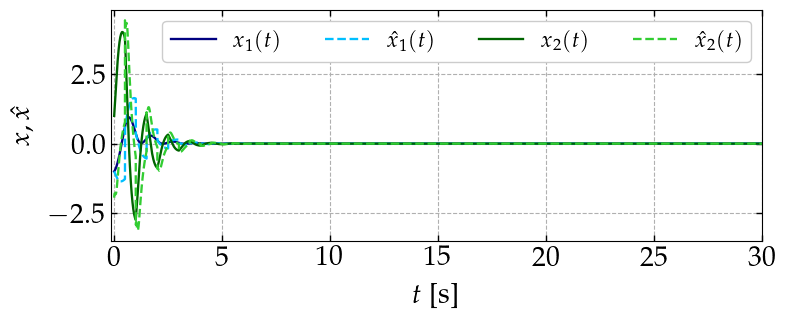

In [8]:
figure_width = 8.4
figure_height = 3.0

plot_style = Graphs.PlotStyle()
plot_style.legend_ncol = 4
plot_style.tick_fontsize = 20
plot_style.label_fontsize = 20
plot_style.legend_fontsize = 16

fig, axs = plt.subplot_mosaic([["x"]], figsize=(figure_width, figure_height))
_ = Graphs.plot(
    axs["x"], time, [x1, x_est1, x2, x_est2],
    label=[r"$x_1(t)$", r"$\hat{x}_1(t)$", r"$x_2(t)$", r"$\hat{x}_2(t)$"],
    xlabel="$t$", x_unit="s", x_use_prefixes=True,
    ylabel=r"$x, \hat{x}$",
    color=["navy", "deepskyblue", "darkgreen", "limegreen"],
    linestyle=["-", "--", "-", "--"], x_pad=(0.005, 0.0), y_pad=(0.05, 0.05),
    style=plot_style,
)

fig_path = "P:/Latex Projects/ExperimentsReports/Figs/E01"
exp_number = 7
plt.savefig(fig_path + "/exp" + str(exp_number) +
            "_plant_states.eps", bbox_inches='tight')

Failed to find a Ghostscript installation.  Distillation step skipped.


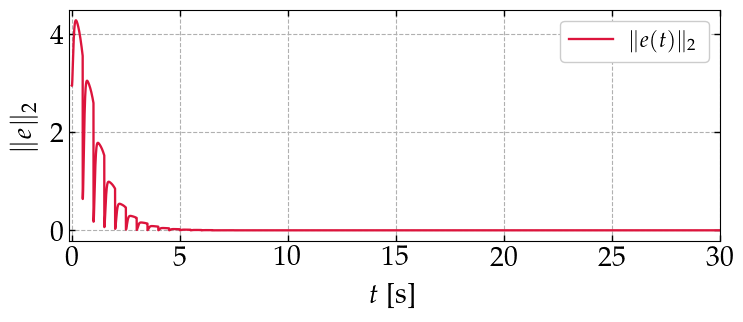

In [9]:
fig, axs = plt.subplot_mosaic([["e"]], figsize=(figure_width, figure_height))
_ = Graphs.plot(
    axs["e"], time, [error_norm],
    label=[r"$\|e(t)\|_2$"],
    xlabel="$t$", x_unit="s", x_use_prefixes=True,
    ylabel=r"$\|e\|_2$",
    color=["crimson"], x_pad=(0.005, 0.0), y_pad=(0.05, 0.05),
    style=plot_style,
)
plt.savefig(fig_path + "/exp" + str(exp_number) +
            "_error_norm.eps", bbox_inches='tight')

Failed to find a Ghostscript installation.  Distillation step skipped.


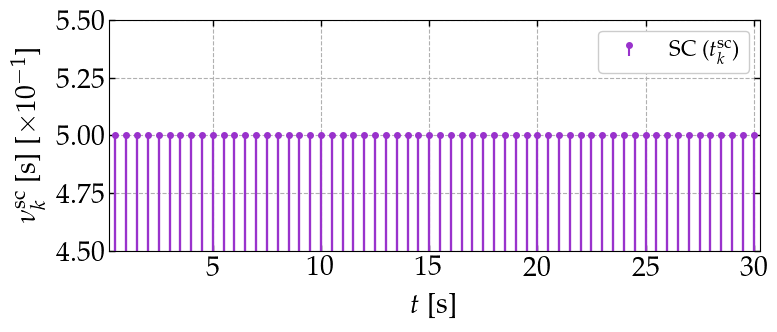

In [10]:
fig, axs = plt.subplot_mosaic(
    [["iet_sc"]], figsize=(figure_width, figure_height))
_ = Graphs.stem(
    axs["iet_sc"], sc_trigger_valid, sc_iet_valid,
    label=[r"SC ($t_k^{\mathrm{sc}}$)"], xlabel="$t$", x_unit="s", x_use_prefixes=True,
    ylabel=r"$\nu_k^{\mathrm{sc}}$ [s]",
    color=["darkorchid"], x_pad=(0.01, 0.01), y_pad=(0.05, 0.05),
    style=plot_style,
)
plt.savefig(fig_path + "/exp" + str(exp_number) +
            "_iet_sc.eps", bbox_inches='tight')

Failed to find a Ghostscript installation.  Distillation step skipped.


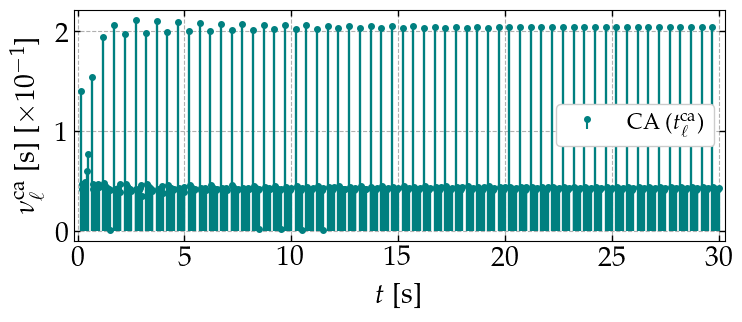

In [11]:
fig, axs = plt.subplot_mosaic(
    [["iet_ca"]], figsize=(figure_width, figure_height))
_ = Graphs.stem(
    axs["iet_ca"], ca_trigger_valid, ca_iet_valid,
    label=[r"CA ($t_\ell^{\mathrm{ca}}$)"],
    xlabel="$t$", x_unit="s", x_use_prefixes=True,
    ylabel=r"$\nu_\ell^{\mathrm{ca}}$ [s]",
    color=["teal"], x_pad=(0.01, 0.01), y_pad=(0.05, 0.05),
    style=plot_style,
)
plt.savefig(fig_path + "/exp" + str(exp_number) +
            "_iet_ca.eps", bbox_inches='tight')

Failed to find a Ghostscript installation.  Distillation step skipped.


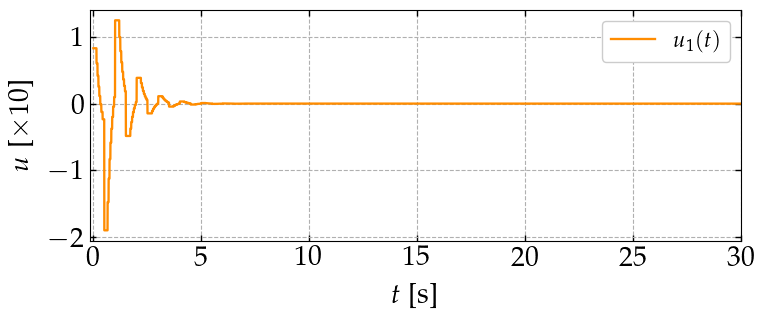

In [12]:
fig, axs = plt.subplot_mosaic([["u"]], figsize=(figure_width, figure_height))
_ = Graphs.plot(
    axs["u"], time, [u1],
    label=[r"$u_1(t)$"],
    xlabel="$t$", x_unit="s", x_use_prefixes=True,
    ylabel=r"$u$", color=["darkorange"], x_pad=(0.005, 0.0), y_pad=(0.05, 0.05),
    style=plot_style,
)
plt.savefig(fig_path + "/exp" + str(exp_number) +
            "_u1.eps", bbox_inches='tight')